<a href="https://colab.research.google.com/github/singhbudhpratap-hash/My-Anotomy-Modules/blob/main/MyAnotomyModule1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imdevskp/covid19-corona-virus-india-dataset")

print("Path to dataset files:", path)

100%|██████████| 3.08M/3.08M [00:00<00:00, 27.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/imdevskp/covid19-corona-virus-india-dataset/versions/186


In [ ]:
import os
print(os.listdir(path))

['state_level_daily.csv', 'state_level_latest.csv', 'patients_data.csv', 'api.ipynb', 'README.md', 'nation_level_daily.csv', 'tests_state_wise.csv', 'complete.csv', 'web_scraping.ipynb', 'district_level_latest.csv', 'tests_day_wise.csv']


In [ ]:
import pandas as pd
file_path=os.path.join(path,"tests_state_wise.csv")
df=pd.read_csv(file_path)

In [ ]:
#undersatnd the dataset
print("Shape", df.shape)
print("Columns", df.columns)
print("Data type", df.dtypes)
print("describe",df.describe)

Shape (3938, 28)
Columns Index(['Updated On', 'State', 'Total Tested', 'Tag (Total Tested)', 'Positive',
       'Negative', 'Unconfirmed', 'Cumulative People In Quarantine',
       'Total People Currently in Quarantine', 'Tag (People in Quarantine)',
       'Total People Released From Quarantine', 'People in ICU',
       'People on Ventilators', 'Num Isolation Beds', 'Num ICU Beds',
       'Num Ventilators', 'Total PPE', 'Total N95 Masks',
       'Corona Enquiry Calls', 'Num Calls State Helpline', 'Source1',
       'Source2', 'Source3', 'Test positivity rate', 'Tests per thousand',
       'Tests per million', 'Tests per positive case',
       'Population NCP 2019 Projection'],
      dtype='object')
Data type Updated On                                object
State                                     object
Total Tested                             float64
Tag (Total Tested)                        object
Positive                                 float64
Negative                             

In [ ]:
df.isnull().sum()

,0
Updated On,0
State,0
Total Tested,61
Tag (Total Tested),29
Positive,75
Negative,1421
Unconfirmed,2219
Cumulative People In Quarantine,3662
Total People Currently in Quarantine,2240
Tag (People in Quarantine),2219


In [ ]:
df["Positive"]=df["Positive"].fillna(0)
print(df["Positive"].isnull().sum())

0


             State  Positive
19     Maharashtra  488670.0
29      Tamil Nadu  279144.0
1   Andhra Pradesh  196789.0
15       Karnataka  158254.0
8            Delhi  141531.0
32   Uttar Pradesh  108974.0
34     West Bengal   86754.0
30       Telangana   73050.0
4            Bihar   68148.0
10         Gujarat   67811.0


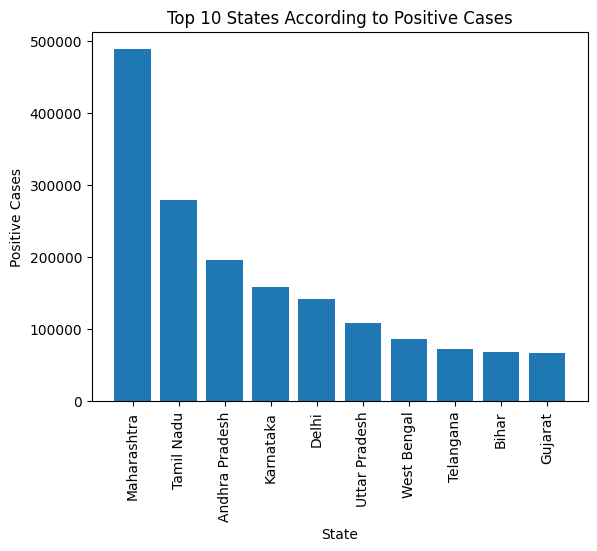

In [ ]:
state_data = df.groupby("State")["Positive"].max().reset_index()
top_10 = state_data.sort_values("Positive", ascending=False).head(10)
print(top_10)

import matplotlib.pyplot as plt
# Top 10 states ka bar graph
plt.bar(top_10["State"], top_10["Positive"])
# X-axis ka label
plt.xlabel("State")
# Y-axis ka label
plt.ylabel("Positive Cases")
plt.title("Top 10 States According to Positive Cases")
plt.xticks(rotation=90)
plt.show()

      Total People Currently in Quarantine  Positive
1365                              321442.0  158254.0
1359                              292039.0  151449.0
1357                              278379.0  145830.0
442                                 2545.0  141531.0
474                                 2884.0  140232.0
1348                              254738.0  139571.0
502                                 3198.0  139156.0
536                                 3579.0  138482.0
580                                 4170.0  137677.0
589                                 4320.0  136716.0


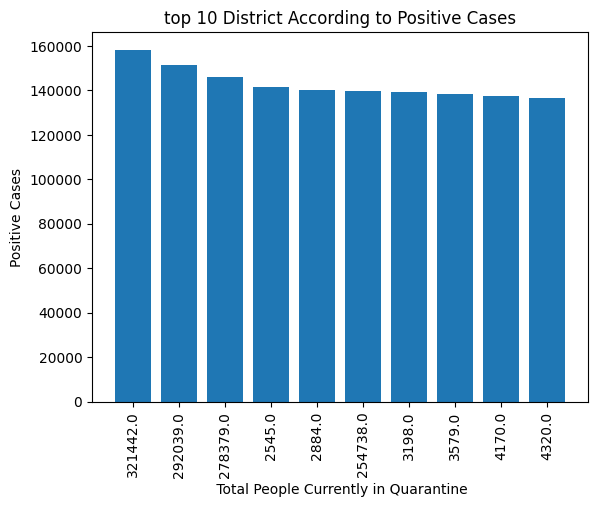

In [ ]:
Quarantine_data =df.groupby("Total People Currently in Quarantine")["Positive"].max().reset_index()
top_10= Quarantine_data.sort_values("Positive",ascending=False).head(10)
print(top_10)

import matplotlib.pyplot as plt
plt.bar(top_10["Total People Currently in Quarantine"].astype(str),top_10["Positive"])
plt.xlabel(" Total People Currently in Quarantine")
plt.ylabel("Positive Cases")
plt.title("top 10 District According to Positive Cases")
plt.xticks(rotation=90)
plt.show()

In [ ]:
import pandas as pd
#import statistics
Employee={
    "Employees":["Rahul","Aarun","Devansh","Jatin","Raghu","Sahil","Arjun","Vijay","Jay","Mohan"],
    "Salary":[20000,30000,50000,40000,60000,30000,80000,10000,70000,80000],
    "Sector":["IT","Sales","IT","Sales","IT","Sales","Sales","IT","Sales","Sales"]
}
df=pd.DataFrame(Employee)
print(df)

#Mean
print("\n--------------Mean---------\n")
print("Mean of salary:\n",df["Salary"].mean())

#Row and column
print("\n-------------Row & colums-------------\n")
print("Numbers of rows and columns:\n", df.shape)

#Salary Range
print("\n--------------row of salary---------\n")
print("Salary rows:\n",df["Salary"])

#Information
print("\n--------------information---------\n")
print("Information about data:\n",df.info)

#Median
print("\n--------------Median-------------\n")
print("Median Salary:\n",df["Salary"].median())

#Mode
print("\n--------------Mode-------------\n")
print("Mode of Salary:\n",df["Salary"].mode())

#Range
print("\n--------------Range-------------\n")           #range=maximum-minimum
salary_range= df["Salary"].max()- df["Salary"].min()
print("Range of Salary:\n",salary_range)

  Employees  Salary Sector
0     Rahul   20000     IT
1     Aarun   30000  Sales
2   Devansh   50000     IT
3     Jatin   40000  Sales
4     Raghu   60000     IT
5     Sahil   30000  Sales
6     Arjun   80000  Sales
7     Vijay   10000     IT
8       Jay   70000  Sales
9     Mohan   80000  Sales

--------------Mean---------

Mean of salary:
 47000.0

-------------Row & colums-------------

Numbers of rows and columns:
 (10, 3)

--------------row of salary---------

Salary rows:
 0    20000
1    30000
2    50000
3    40000
4    60000
5    30000
6    80000
7    10000
8    70000
9    80000
Name: Salary, dtype: int64

--------------information---------

Information about data:
 <bound method DataFrame.info of   Employees  Salary Sector
0     Rahul   20000     IT
1     Aarun   30000  Sales
2   Devansh   50000     IT
3     Jatin   40000  Sales
4     Raghu   60000     IT
5     Sahil   30000  Sales
6     Arjun   80000  Sales
7     Vijay   10000     IT
8       Jay   70000  Sales
9     Mohan   8